In [ ]:
# Chargement et exploration des données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#importation
data = pd.read_csv("../data/Clean_Dataset.csv")

#dimensions
print("Number of rows :", data.shape[0])
print("Number of columns :", data.shape[1])

#premiere observation
print("\nFirst 5 rows:")
print(data.head())

#types of variables
print("\nDataset information:")
data.info()

#missing values
print("\nMissing values:")
print(data.isnull().sum())
print("\n")
print(data.isna().sum())

#description
print("\nDescriptive statistics:")
print(data.describe())

In [ ]:
#Classification des variables

#variable Discrete :

# airline
# flight
# source_city
# departure_time
# stops
# arrival_time
# destination_city
# class

# variable Continue :

# duration
# days_left
# price

# variable cible :      price
# identifiant :     unamed

In [ ]:
discrete_variables = [
    "airline",
    "flight",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"
]

for col in discrete_variables:

    print(f"\n======={col}=======")
    print("Number of categories :",data[col].nunique())
    print("Categories :",data[col].unique())
    freq = data[col].value_counts()
    table = pd.DataFrame({
        "Effectif": freq,
        "Pourcentage": freq / len(data) * 100
    })
    print(table)
    if col=='flight':
        flight_counts = data[col].value_counts().head(10)

        flight_counts.plot(
            kind="bar",
            figsize=(10, 5),
            title="Top 10 flights les plus fréquents"
        )

        plt.xlabel(col)
        plt.ylabel("Effectif")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8,5))
        sns.countplot(data=data,x=col,order=data[col].value_counts().index)
        plt.title(f"Répartition de {col}")
        plt.xlabel(col)
        plt.ylabel("Nombre d'observations")
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

In [ ]:
continue_variables = [
    "duration",
    "days_left",
    "price"
]

for col in continue_variables:

    print(f"\n======={col}=======")
    print(data[col].describe())

    plt.figure(figsize=(8, 5))
    sns.histplot(data=data, x=col, bins=30, kde=True)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

    plt.figure(figsize=(8, 3))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot de {col}")
    
    if col == "duration":
        plt.xlabel("Durée")
    elif col == "days_left":
        plt.xlabel("Jours avant le vol")
    else:
        plt.xlabel("Prix")
    
    plt.show()

    print("Skewness :", data[col].skew())

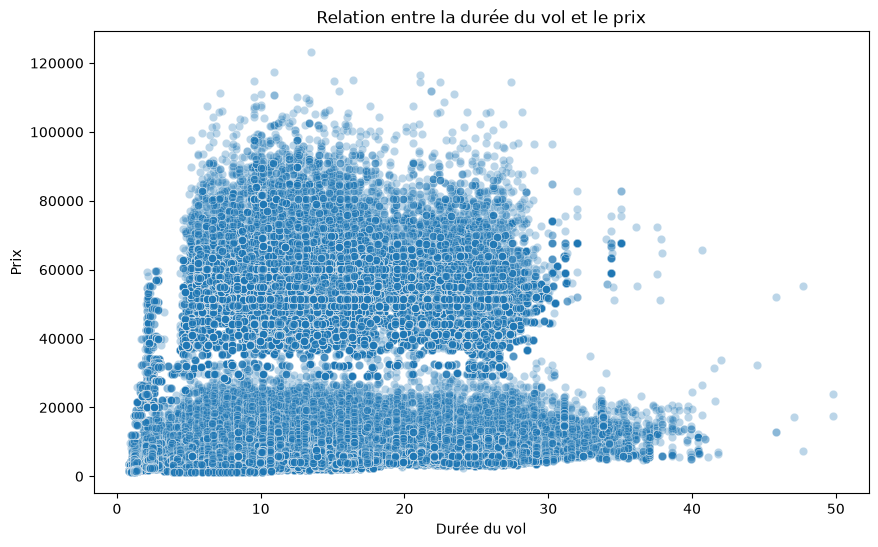

correnation entre duration et price : 0.20422236784542716


In [ ]:
#Analyse multivariee

#duration vs price

import pandas as pd                                                                              
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../data/Clean_Dataset.csv")


plt.figure(figsize=(10, 6))
sns.scatterplot(data=data,x="duration",y="price",alpha=0.3)
plt.title("Relation entre la durée du vol et le prix")
plt.xlabel("Durée du vol")
plt.ylabel("Prix")
plt.show()

correlation=data["duration"].corr(data["price"])
print("correlation entre duration et price :", correlation)


airline
Vistara      30396.536302
Air_India    23507.019112
SpiceJet      6179.278881
GO_FIRST      5652.007595
Indigo        5324.216303
AirAsia       4091.072742
Name: price, dtype: float64


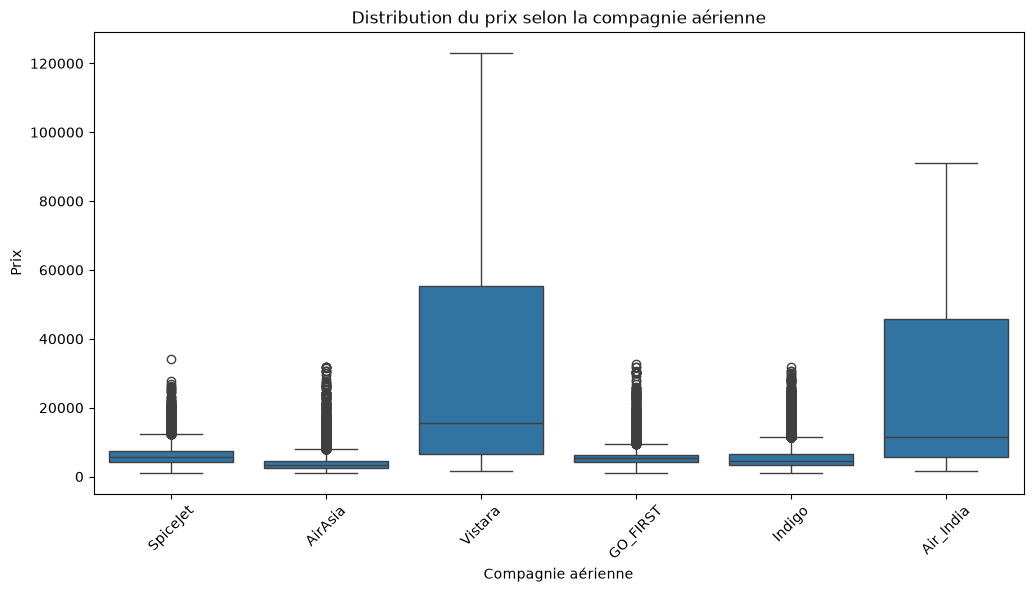

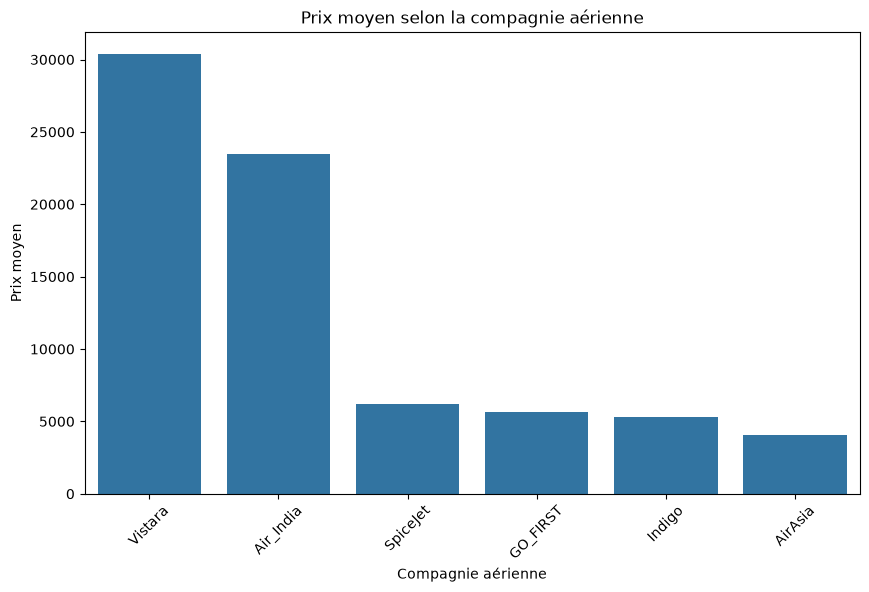

In [15]:
#airline vs price

plt.figure(figsize=(12,6))
sns.boxplot(data=data,x="airline",y="price")
plt.title("Distribution du prix selon la compagnie aérienne")
plt.xlabel("Compagnie aérienne")
plt.ylabel("Prix")
plt.xticks(rotation=45)
plt.show

airline_price = (data.groupby("airline")["price"].mean().sort_values(ascending=False))
print(airline_price)

plt.figure(figsize=(10, 6))
sns.barplot(x=airline_price.index,y=airline_price.values)
plt.title("Prix moyen selon la compagnie aérienne")
plt.xlabel("Compagnie aérienne")
plt.ylabel("Prix moyen")
plt.xticks(rotation=45)
plt.show()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64


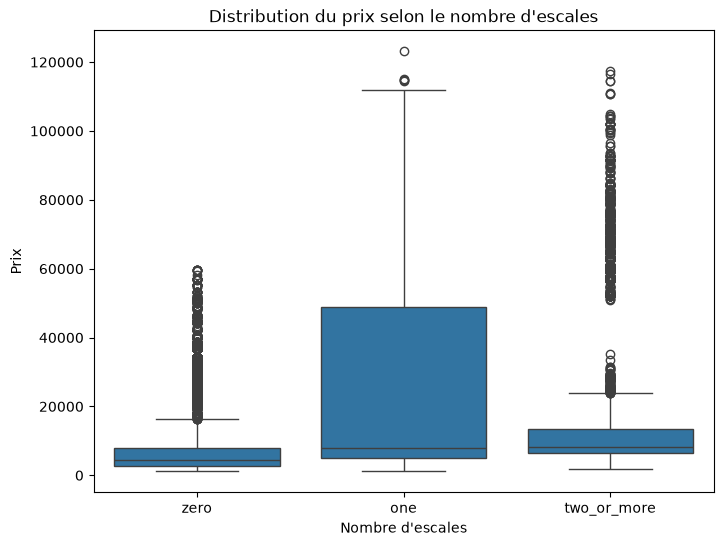

stops
zero            9375.938535
two_or_more    14113.450775
one            22900.992482
Name: price, dtype: float64


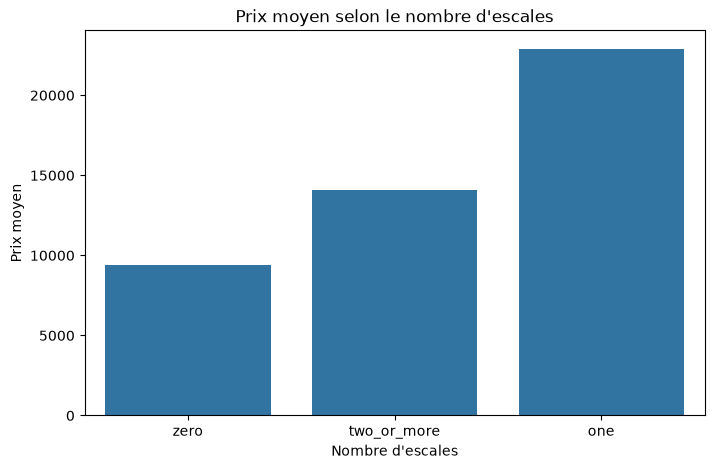

In [3]:
#stops vs price
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../data/Clean_Dataset.csv")

print(data["stops"].value_counts())

plt.figure(figsize=(8, 6))
sns.boxplot(data=data,x="stops",y="price")
plt.title("Distribution du prix selon le nombre d'escales")
plt.xlabel("Nombre d'escales")
plt.ylabel("Prix")
plt.show()

stops_price = (data.groupby("stops")["price"].mean().sort_values())
print(stops_price)

plt.figure(figsize=(8, 5))
sns.barplot(x=stops_price.index,y=stops_price.values)
plt.title("Prix moyen selon le nombre d'escales")
plt.xlabel("Nombre d'escales")
plt.ylabel("Prix moyen")
plt.show()

class
Economy     206666
Business     93487
Name: count, dtype: int64


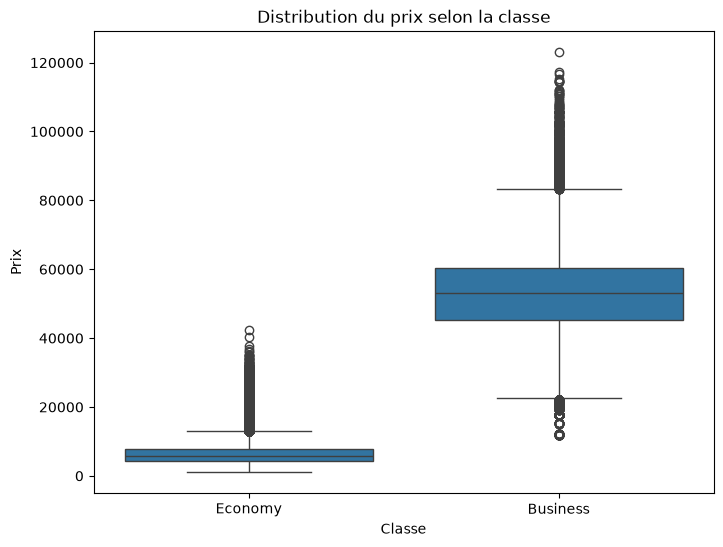

In [5]:
#class vs price
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../data/Clean_Dataset.csv")

print(data["class"].value_counts())

plt.figure(figsize=(8, 6))
sns.boxplot(data=data,x="class",y="price")
plt.title("Distribution du prix selon la classe")
plt.xlabel("Classe")
plt.ylabel("Prix")

plt.show()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64


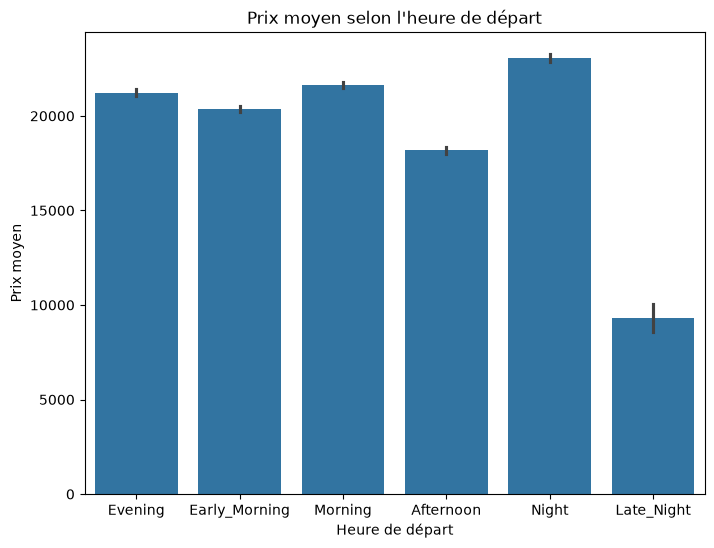

In [10]:
# departure_time vs price
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../data/Clean_Dataset.csv")

print(data["departure_time"].value_counts())

plt.figure(figsize=(8, 6))
sns.barplot(data=data, x="departure_time", y="price")
plt.title("Prix moyen selon l'heure de départ")
plt.xlabel("Heure de départ")
plt.ylabel("Prix moyen")

plt.show()

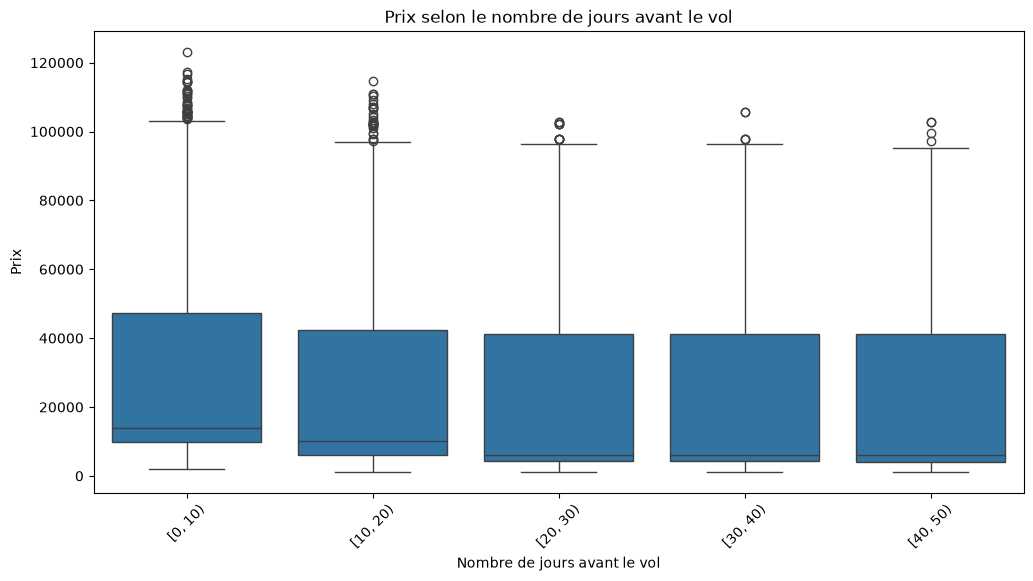

In [19]:
#days_left vs price
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../data/Clean_Dataset.csv")

bins = range(0, data["days_left"].max() + 10, 10)
data["days_group"] = pd.cut(data["days_left"],bins=bins,right=False)

plt.figure(figsize=(12, 6))
sns.boxplot(data=data,x="days_group",y="price")
plt.title("Prix selon le nombre de jours avant le vol")
plt.xlabel("Nombre de jours avant le vol")
plt.ylabel("Prix")
plt.xticks(rotation=45)
plt.show()
